# Real-data reconstruction figures

Plot and save `.eps` figures of the real-data reconstructions computed in `experimental_data_analysis.ipynb` — **RD MAP maps** and **diffPIR posterior means** at different time slices. Everything is loaded from the saved `.npy` arrays; nothing is recomputed.

Datasets:
- **Shot 85270** — full discharge, 28 frames (`im_maps_<variant>_sigma025.npy`, `posterior_tomo_<variant>_sigma025.npy`, variant = `core_mask` or `tcv_mask`)
- **Shot 88767 (fine time grid)** — baseline profiles, 10 slices (`*_shot2.npy`)
- **Shot 88767 (fine time grid)** — fluctuations, 10 slices (`*_shot2_fluctuations.npy`)

diffPIR posteriors are stored in normalized units; multiplying by the per-slice normalization `params[:, 0]` (alpha) brings them to the same units as the RD maps.

In [1]:
%cd ../..

/home/fusiontomo/Repos/diffusion_tomography


In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import scipy.io as scio
from scipy import ndimage

from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

figs_dir = Path("results_images/real_data/figs")
figs_dir.mkdir(parents=True, exist_ok=True)

In [3]:
def preprocess_magnetic_data(data_exp, Nz, Nr, doublet=False):
    # interpolate original equilibria on the prescribed inversion grid
    eqs = np.zeros((data_exp["psi"].shape[2], Nz, Nr))
    rs = data_exp['liuqe_rs'][:, 0]
    zs = data_exp['liuqe_zs'][:, 0]
    dr_liuqe = np.mean(np.diff(rs.flatten()))
    dz_liuqe = np.mean(np.diff(zs.flatten()))
    tcv_zmin, tcv_zmax = -0.75, 0.75
    tcv_rmin, tcv_rmax = 0.624, 1.1376
    dz, dr = (tcv_zmax - tcv_zmin) / Nz, (tcv_rmax - tcv_rmin) / Nr
    tcv_Zs = np.linspace(tcv_zmin, tcv_zmax, Nz + 1, endpoint=True)[:-1] + dz / 2
    tcv_Rs = np.linspace(tcv_rmin, tcv_rmax, Nr + 1, endpoint=True)[:-1] + dr / 2
    for i in range(data_exp['psi'].shape[2]):
        r_pos_evals = (tcv_Rs - rs.min()) / dr_liuqe
        z_pos_evals = -(np.flip(tcv_Zs) - zs.max()) / dz_liuqe
        coord_eval_pos = np.zeros((2, Nz * Nr))
        for nz in range(Nz):
            for nr in range(Nr):
                coord_eval_pos[0, nr + nz * Nr] = z_pos_evals[nz]
                coord_eval_pos[1, nr + nz * Nr] = r_pos_evals[nr]
        if doublet:
            eqs[i, :, :] = ndimage.map_coordinates(np.flip(data_exp['psi'][:, :, i], axis=0),
                                                   coord_eval_pos, order=2, mode="nearest",
                                                   prefilter=True).reshape(Nz, Nr)
        else:
            eqs[i, :, :] = ndimage.map_coordinates(np.flip(data_exp['psi'][:, :, i].T, axis=0),
                                                   coord_eval_pos, order=2, mode="nearest",
                                                   prefilter=True).reshape(Nz, Nr)
    return eqs


def save_profile_eps(img, psi_slice, fname, cmap="viridis", vmin=None, vmax=None, contour_color="w"):
    # single-panel figure, saved as eps (same style as results_images/prior_samples)
    plt.figure(figsize=(3, 3))
    tomo_plots.plot_profile(np.asarray(img), tcv_plot_clip=True,
                            contour_image=psi_slice, cmap=cmap, ax=None,
                            colorbar=False, contour_color=contour_color, vmin=vmin, vmax=vmax,
                            aspect=None, lcfs_width=1, lwidth=0.2)
    plt.axis('off')
    plt.savefig(figs_dir / fname, format='eps', bbox_inches="tight")
    plt.close()


def overview_row(images, psis, times, suptitle, fname, cmap="viridis", vmin=None, vmax=None, contour_color="w"):
    # inline overview of all panels of a dataset + saved eps
    n = len(images)
    fig, ax = plt.subplots(1, n, figsize=(2 * n, 5))
    if n == 1:
        ax = [ax]
    for i in range(n):
        tomo_plots.plot_profile(np.asarray(images[i]), tcv_plot_clip=True,
                                contour_image=psis[i], cmap=cmap, ax=ax[i],
                                colorbar=False, contour_color=contour_color, vmin=vmin, vmax=vmax,
                                aspect=None, lcfs_width=1, lwidth=0.2)
        ax[i].set_title("t={:.3f}s".format(times[i]), fontsize=9)
        ax[i].axis('off')
    fig.suptitle(suptitle)
    plt.tight_layout()
    plt.savefig(figs_dir / fname, format='eps', bbox_inches="tight")
    plt.show()

## Shot 85270 - full discharge (28 frames)

In [4]:
variant = "core_mask"   # or "tcv_mask"

im_maps_85270  = np.load(f"im_maps_{variant}_sigma025.npy").squeeze()             # (28, H, W)
posterior_85270 = np.load(f"posterior_tomo_{variant}_sigma025.npy")               # (28, 100, 1, H, W)
params_85270   = np.load(f"params_{variant}_sigma025.npy")                        # (28, 3): [alpha, anis, sigma]

# diffPIR posterior mean, brought back to the RD-map units via alpha
post_mean_85270 = posterior_85270.mean(axis=1).squeeze() * params_85270[:, 0, None, None]  # (28, H, W)

exp_data_85270 = scio.loadmat("experimental_data/shot_data_85270.mat")["data"][0, 0]
times_85270 = exp_data_85270["measurements_times"].flatten()                       # (28,)
psi_85270 = preprocess_magnetic_data(exp_data_85270, Nz=120, Nr=40, doublet=False)

print(im_maps_85270.shape, post_mean_85270.shape, times_85270.shape, psi_85270.shape)

(28, 120, 40) (28, 120, 40) (28,) (28, 120, 40)


<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

...

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

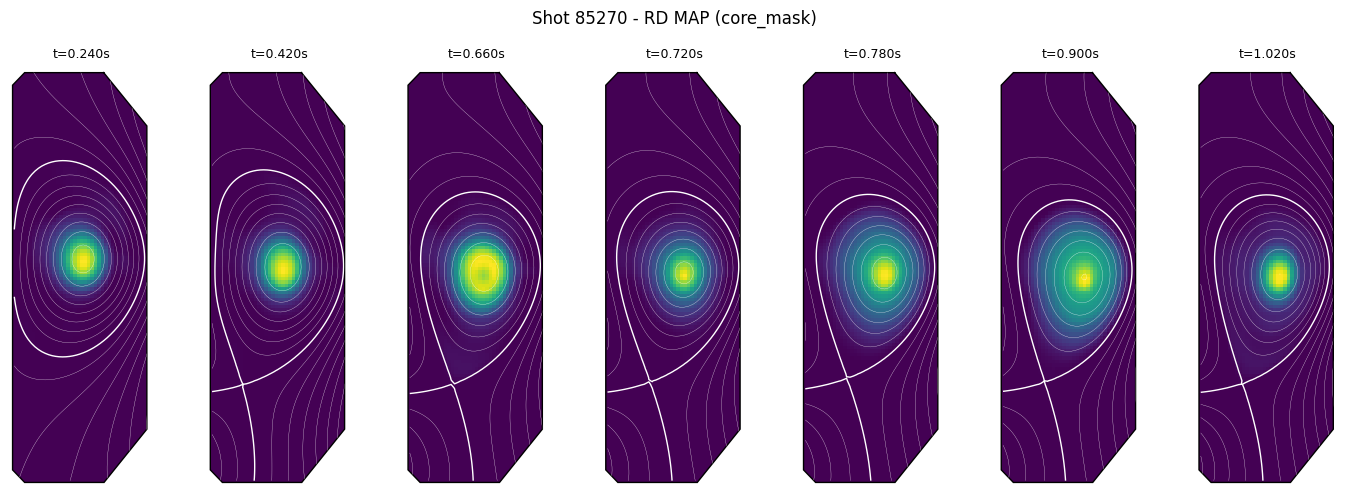

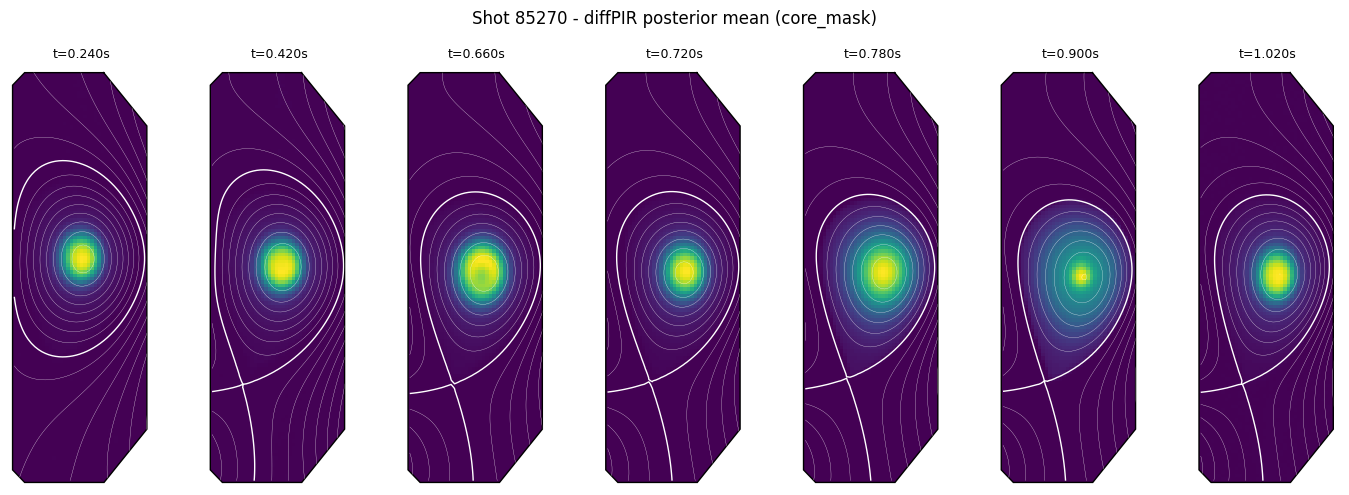

saved 16 eps files to results_images/real_data/figs


In [5]:
# time slices to plot/save
plot_idxs_85270 = np.array([3,6, 10, 11, 12,14, 16]) #np.arange(0, len(times_85270), 1)

for i in plot_idxs_85270:
    t_ms = int(round(times_85270[i] * 1000))
    save_profile_eps(im_maps_85270[i],  psi_85270[i], f"shot85270_{variant}_t{t_ms}ms_rd.eps")
    save_profile_eps(post_mean_85270[i], psi_85270[i], f"shot85270_{variant}_t{t_ms}ms_diffpir.eps")

overview_row([im_maps_85270[i] for i in plot_idxs_85270],
             [psi_85270[i] for i in plot_idxs_85270],
             times_85270[plot_idxs_85270],
             f"Shot 85270 - RD MAP ({variant})",
             f"shot85270_{variant}_rd_overview.eps")

overview_row([post_mean_85270[i] for i in plot_idxs_85270],
             [psi_85270[i] for i in plot_idxs_85270],
             times_85270[plot_idxs_85270],
             f"Shot 85270 - diffPIR posterior mean ({variant})",
             f"shot85270_{variant}_diffpir_overview.eps")

print(f"saved {2 * len(plot_idxs_85270) + 2} eps files to {figs_dir}")

## Shot 88767 (fine time grid) - baseline profiles (10 slices)

In [6]:
im_maps_bl  = np.load("im_maps_core_mask_sigma025_shot2.npy").squeeze()            # (10, H, W)
posterior_bl = np.load("posterior_tomo_core_mask_sigma025_shot2.npy")              # (10, 100, 1, H, W)
params_bl   = np.load("params_core_mask_sigma025_shot2.npy")                       # (10, 3)
times_bl    = np.load("inv_times_core_mask_sigma025_shot2.npy")[1:2]                   # (10,)

post_mean_bl = posterior_bl.mean(axis=1).squeeze() * params_bl[:, 0, None, None]

exp_data_88767 = scio.loadmat("experimental_data/shot_data_88767_finetimegrid.mat")["data"][0, 0]
times_all_88767 = exp_data_88767["measurements_times"].flatten()
psi_88767 = preprocess_magnetic_data(exp_data_88767, Nz=120, Nr=40, doublet=False)

# match saved inversion times to the equilibrium time base
psi_idx_bl = np.array([np.argmin(np.abs(times_all_88767 - t)) for t in times_bl])
print(im_maps_bl.shape, post_mean_bl.shape, times_bl, psi_idx_bl)

(11, 120, 40) (11, 120, 40) [1.00010002] [0]


<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

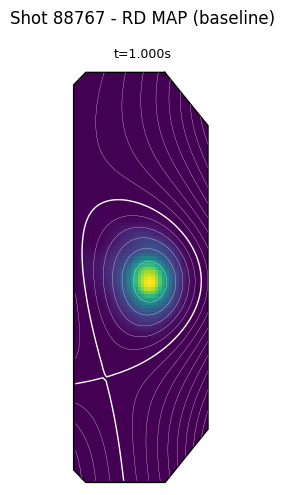

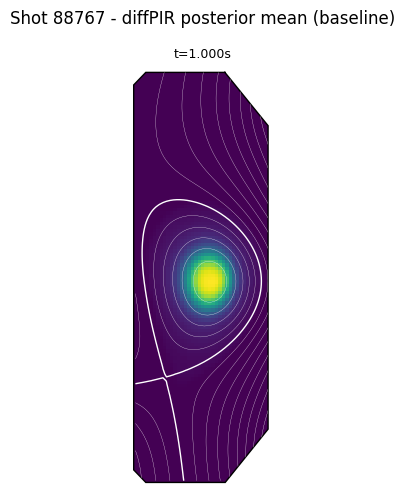

saved 4 eps files to results_images/real_data/figs


In [7]:
for k, t in enumerate(times_bl):
    t_ms = int(round(t * 1000))
    save_profile_eps(im_maps_bl[k],  psi_88767[psi_idx_bl[k]], f"shot88767_baseline_t{t_ms}ms_rd.eps")
    save_profile_eps(post_mean_bl[k], psi_88767[psi_idx_bl[k]], f"shot88767_baseline_t{t_ms}ms_diffpir.eps")

overview_row([im_maps_bl[k] for k in range(len(times_bl))],
             [psi_88767[i] for i in psi_idx_bl],
             times_bl,
             "Shot 88767 - RD MAP (baseline)",
             "shot88767_baseline_rd_overview.eps")

overview_row([post_mean_bl[k] for k in range(len(times_bl))],
             [psi_88767[i] for i in psi_idx_bl],
             times_bl,
             "Shot 88767 - diffPIR posterior mean (baseline)",
             "shot88767_baseline_diffpir_overview.eps")

print(f"saved {2 * len(times_bl) + 2} eps files to {figs_dir}")

## Shot 88767 (fine time grid) - fluctuations (10 slices)

In [8]:
im_maps_fl  = np.load("im_maps_core_mask_sigma025_shot2_fluctuations.npy").squeeze()
posterior_fl = np.load("posterior_tomo_core_mask_sigma025_shot2_fluctuations.npy")
params_fl   = np.load("params_core_mask_sigma025_shot2_fluctuations.npy")
times_fl    = np.load("inv_times_core_mask_sigma025_shot2_fluctuations.npy")[2:7]

post_mean_fl = posterior_fl.mean(axis=1).squeeze() * params_fl[:, 0, None, None]

psi_idx_fl = np.array([np.argmin(np.abs(times_all_88767 - t)) for t in times_fl])

# fluctuation maps can be signed: use a symmetric diverging colormap if needed
def cmap_and_limits(imgs):
    # white contours on dark viridis; gray contours on the light diverging map
    vmax = np.max(np.abs(imgs))
    if imgs.min() < -0.05 * imgs.max():
        return "RdBu_r", -vmax, vmax, "dimgray"
    return "viridis", None, None, "w"

cmap_rd, vmin_rd, vmax_rd, cc_rd = cmap_and_limits(im_maps_fl)
cmap_dp, vmin_dp, vmax_dp, cc_dp = cmap_and_limits(post_mean_fl)
print("RD:", cmap_rd, "| diffPIR:", cmap_dp)
print(im_maps_fl.shape, post_mean_fl.shape, times_fl)

RD: viridis | diffPIR: RdBu_r
(10, 120, 40) (10, 120, 40) [1.03709996 1.0381     1.03910005 1.04009998 1.04110003]


<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

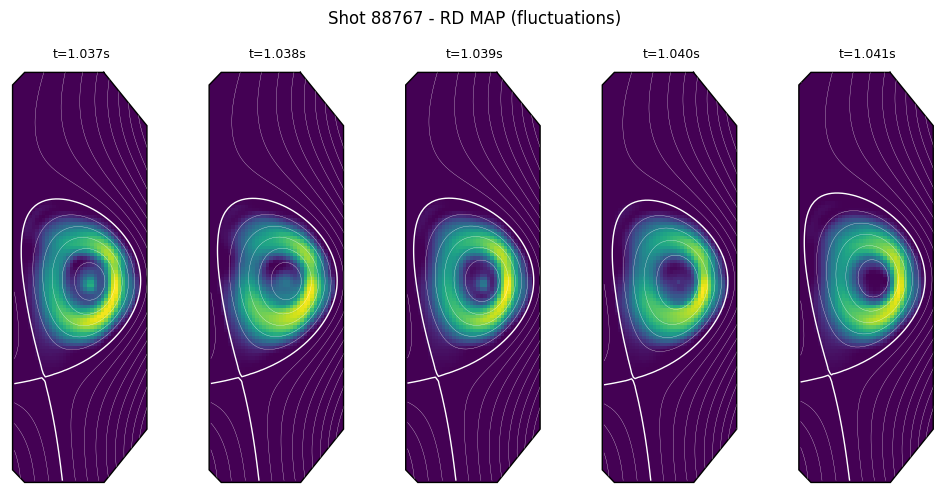

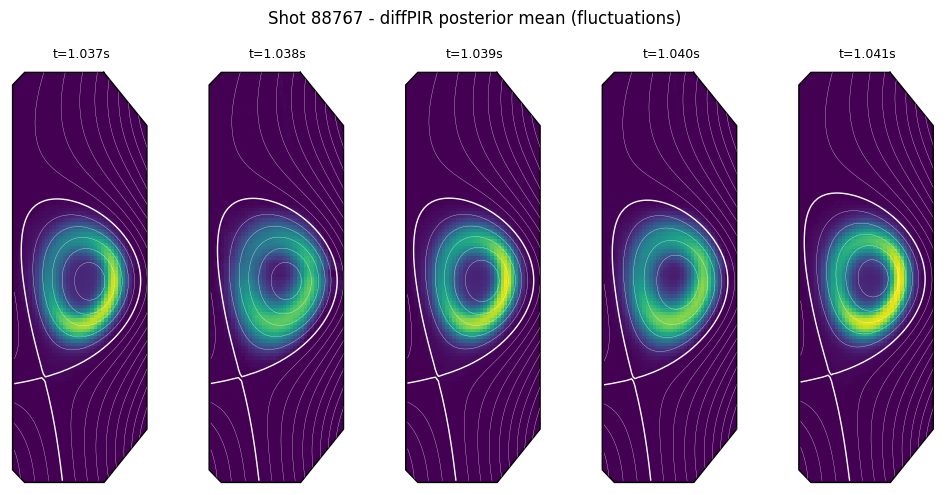

saved 12 eps files to results_images/real_data/figs


In [11]:
for k, t in enumerate(times_fl):
    t_ms = int(round(t * 1000))
    save_profile_eps(im_maps_fl[k], psi_88767[psi_idx_fl[k]], f"shot88767_fluct_t{t_ms}ms_rd.eps",
                     cmap=cmap_rd, vmin=0, vmax=vmax_rd, contour_color=cc_rd)
    save_profile_eps(post_mean_fl[k], psi_88767[psi_idx_fl[k]], f"shot88767_fluct_t{t_ms}ms_diffpir.eps",
                     cmap=cmap_rd, vmin=0, vmax=vmax_dp, contour_color=cc_rd)

overview_row([im_maps_fl[k] for k in range(len(times_fl))],
             [psi_88767[i] for i in psi_idx_fl],
             times_fl,
             "Shot 88767 - RD MAP (fluctuations)",
             "shot88767_fluct_rd_overview.eps",
             cmap=cmap_rd, vmin=0, vmax=vmax_rd, contour_color=cc_rd)

overview_row([post_mean_fl[k] for k in range(len(times_fl))],
             [psi_88767[i] for i in psi_idx_fl],
             times_fl,
             "Shot 88767 - diffPIR posterior mean (fluctuations)",
             "shot88767_fluct_diffpir_overview.eps",
             cmap=cmap_rd, vmin=0, vmax=vmax_dp, contour_color=cc_rd)

print(f"saved {2 * len(times_fl) + 2} eps files to {figs_dir}")